# Exploratory Data Analysis - Network Intrusion Detection

This notebook profiles the labelled flow dataset used to train the detector: class balance, feature distributions, correlation structure, separability under PCA and data quality.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))

from src.data.loader import load_or_generate
from src.features.engineer import engineer_features

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120
TARGET = 'label'

## 1. Load the dataset

In [2]:
data_path = Path.cwd().parent / 'data' / 'raw' / 'flows.csv'
flows = load_or_generate(data_path, n_rows=50_000)
print(f'Shape: {flows.shape[0]:,} rows x {flows.shape[1]} columns')
flows.head()

2026-07-27 23:39:21 | INFO     | src.data.loader:load_dataset - Loaded 50000 rows and 42 columns from /Users/oresajooluwaferanmiidunuoluwa/Downloads/cyb/nids-ml/data/raw/flows.csv


Shape: 50,000 rows x 42 columns


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0.92,tcp,private,S0,56,0,0,0,0,0,...,244,0.869646,0.041804,0.624698,0.000000,0.907036,0.989769,0.000000,0.000000,dos
1,18.69,tcp,http,OTH,113,3834,0,0,0,1,...,190,0.988116,0.000000,0.126644,0.000000,0.034363,0.075060,0.057561,0.047522,normal
2,23.77,udp,domain_u,SF,480,314,0,0,0,0,...,208,0.883280,0.105518,0.239518,0.094031,0.038649,0.000000,0.000000,0.140133,normal
3,26.54,tcp,ftp_data,SF,119,737,0,0,0,0,...,172,0.998146,0.064931,0.208629,0.109345,0.006354,0.000000,0.025157,0.048436,normal
4,0.05,tcp,private,S0,112,0,0,0,0,0,...,226,0.916018,0.073463,0.807567,0.010614,0.914171,0.928460,0.000000,0.078555,dos


## 2. Class distribution

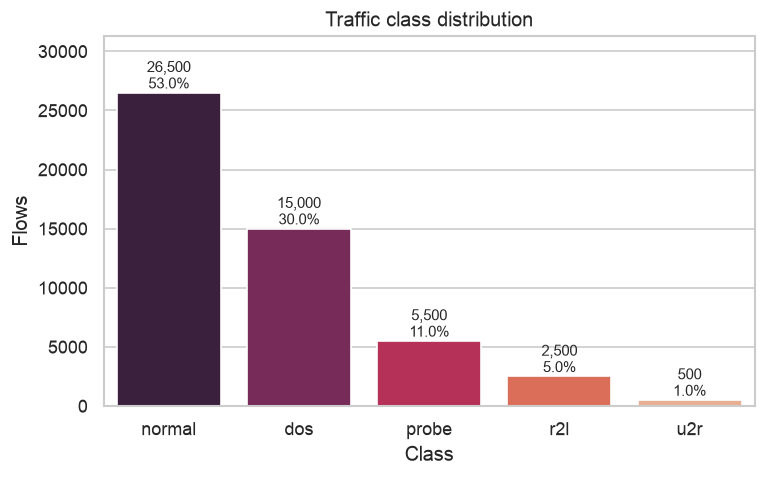

In [3]:
counts = flows[TARGET].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=counts.index, y=counts.to_numpy(), hue=counts.index, palette='rocket',
            legend=False, ax=ax)
for index, value in enumerate(counts.to_numpy()):
    ax.text(index, value, f'{value:,}\n{value / len(flows):.1%}', ha='center', va='bottom',
            fontsize=9)
ax.set_title('Traffic class distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Flows')
ax.set_ylim(0, counts.max() * 1.18)
plt.show()

## 3. Missing values and data quality

In [4]:
quality = pd.DataFrame({
    'dtype': flows.dtypes.astype(str),
    'missing': flows.isna().sum(),
    'missing_pct': (flows.isna().mean() * 100).round(3),
    'unique': flows.nunique(),
})
print(f'Duplicate rows: {flows.duplicated().sum():,}')
print(f'Columns with missing values: {(quality["missing"] > 0).sum()}')
quality.sort_values('missing', ascending=False).head(15)

Duplicate rows: 0
Columns with missing values: 0


,dtype,missing,missing_pct,unique
duration,float64,0,0.0,8140
dst_host_count,int64,0,0.0,255
srv_count,int64,0,0.0,415
serror_rate,float64,0,0.0,38979
srv_serror_rate,float64,0,0.0,38825
rerror_rate,float64,0,0.0,38179
srv_rerror_rate,float64,0,0.0,38342
same_srv_rate,float64,0,0.0,42656
diff_srv_rate,float64,0,0.0,39922
srv_diff_host_rate,float64,0,0.0,42452


## 4. Summary statistics

In [5]:
flows.describe().T.round(3).head(20)

,count,mean,std,min,25%,50%,75%,max
duration,50000.0,19.175,34.442,0.0,0.5,8.82,25.892,706.8
src_bytes,50000.0,380.660,1120.968,0.0,24.0,89.00,339.000,104881.0
dst_bytes,50000.0,1341.454,12907.841,0.0,0.0,113.00,791.000,1774877.0
land,50000.0,0.003,0.055,0.0,0.0,0.00,0.000,1.0
wrong_fragment,50000.0,0.073,0.406,0.0,0.0,0.00,0.000,3.0
urgent,50000.0,0.000,0.000,0.0,0.0,0.00,0.000,0.0
hot,50000.0,0.328,1.191,0.0,0.0,0.00,0.000,19.0
num_failed_logins,50000.0,0.090,0.500,0.0,0.0,0.00,0.000,8.0
logged_in,50000.0,0.421,0.494,0.0,0.0,0.00,1.000,1.0
num_compromised,50000.0,0.031,0.351,0.0,0.0,0.00,0.000,9.0


## 5. Correlation structure

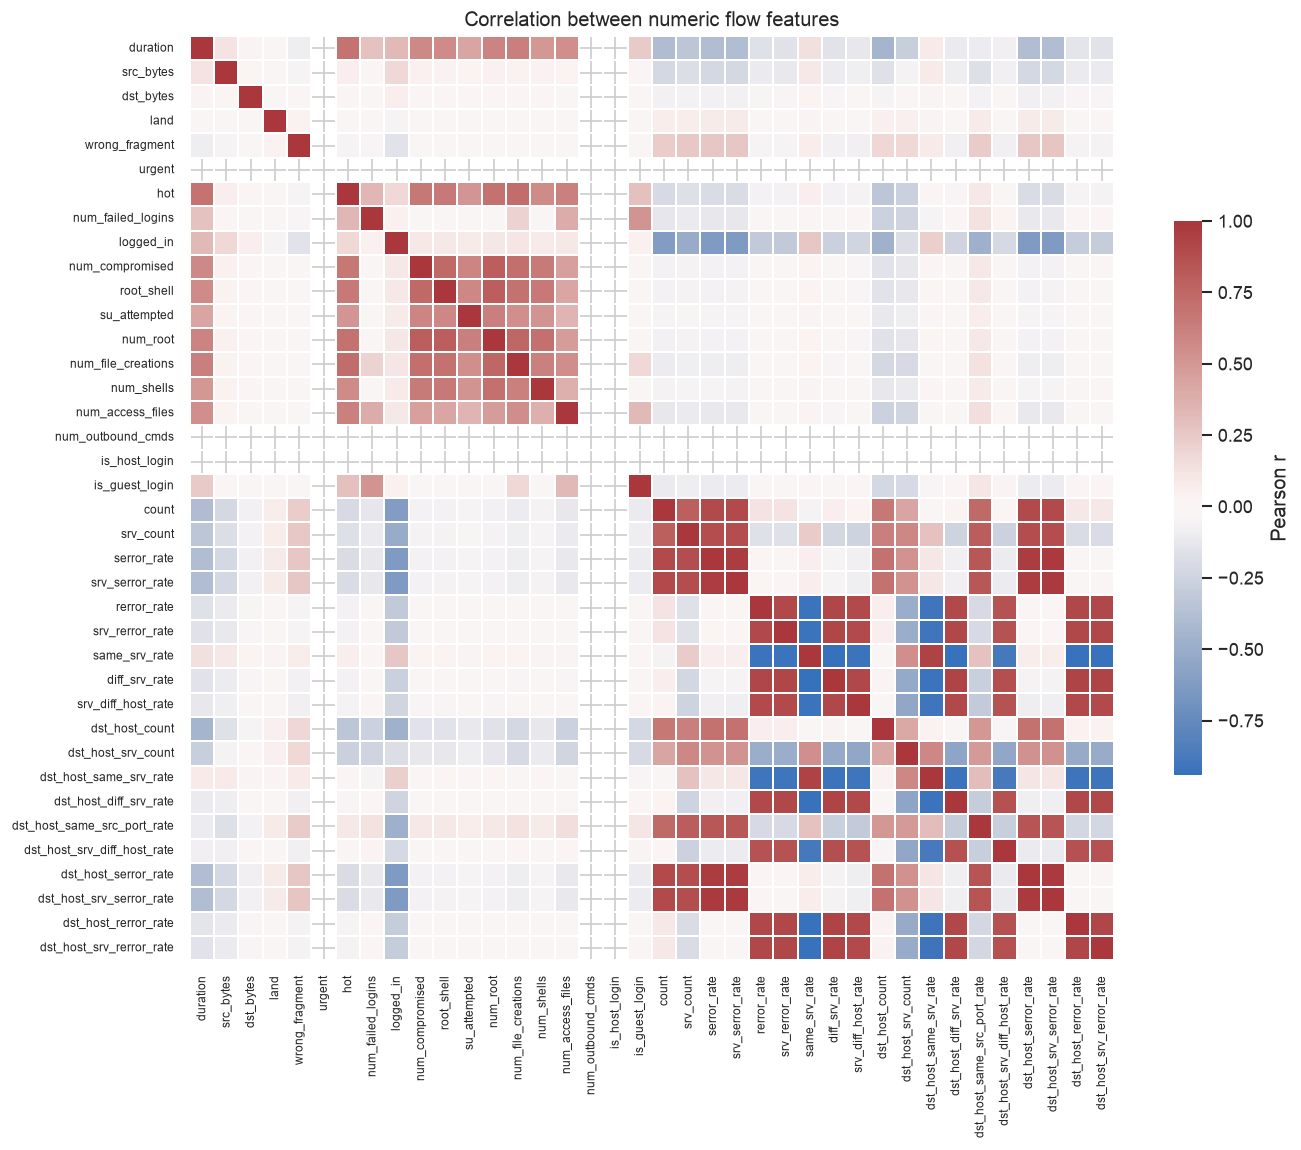

In [6]:
numeric = flows.select_dtypes(include=[np.number])
correlation = numeric.corr()
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(correlation, cmap='vlag', center=0, square=True, linewidths=0.2,
            cbar_kws={'shrink': 0.6, 'label': 'Pearson r'}, ax=ax)
ax.set_title('Correlation between numeric flow features')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.show()

## 6. Feature distributions by class

In [7]:
from sklearn.feature_selection import mutual_info_classif

scores = mutual_info_classif(numeric.fillna(0), flows[TARGET], random_state=42)
top_features = pd.Series(scores, index=numeric.columns).nlargest(10)
top_features.round(4)

serror_rate                    0.8643
srv_serror_rate                0.8640
dst_host_serror_rate           0.8627
dst_host_srv_serror_rate       0.8618
count                          0.8447
dst_bytes                      0.7982
duration                       0.7672
srv_count                      0.7475
dst_host_count                 0.7465
dst_host_same_src_port_rate    0.6934
dtype: float64

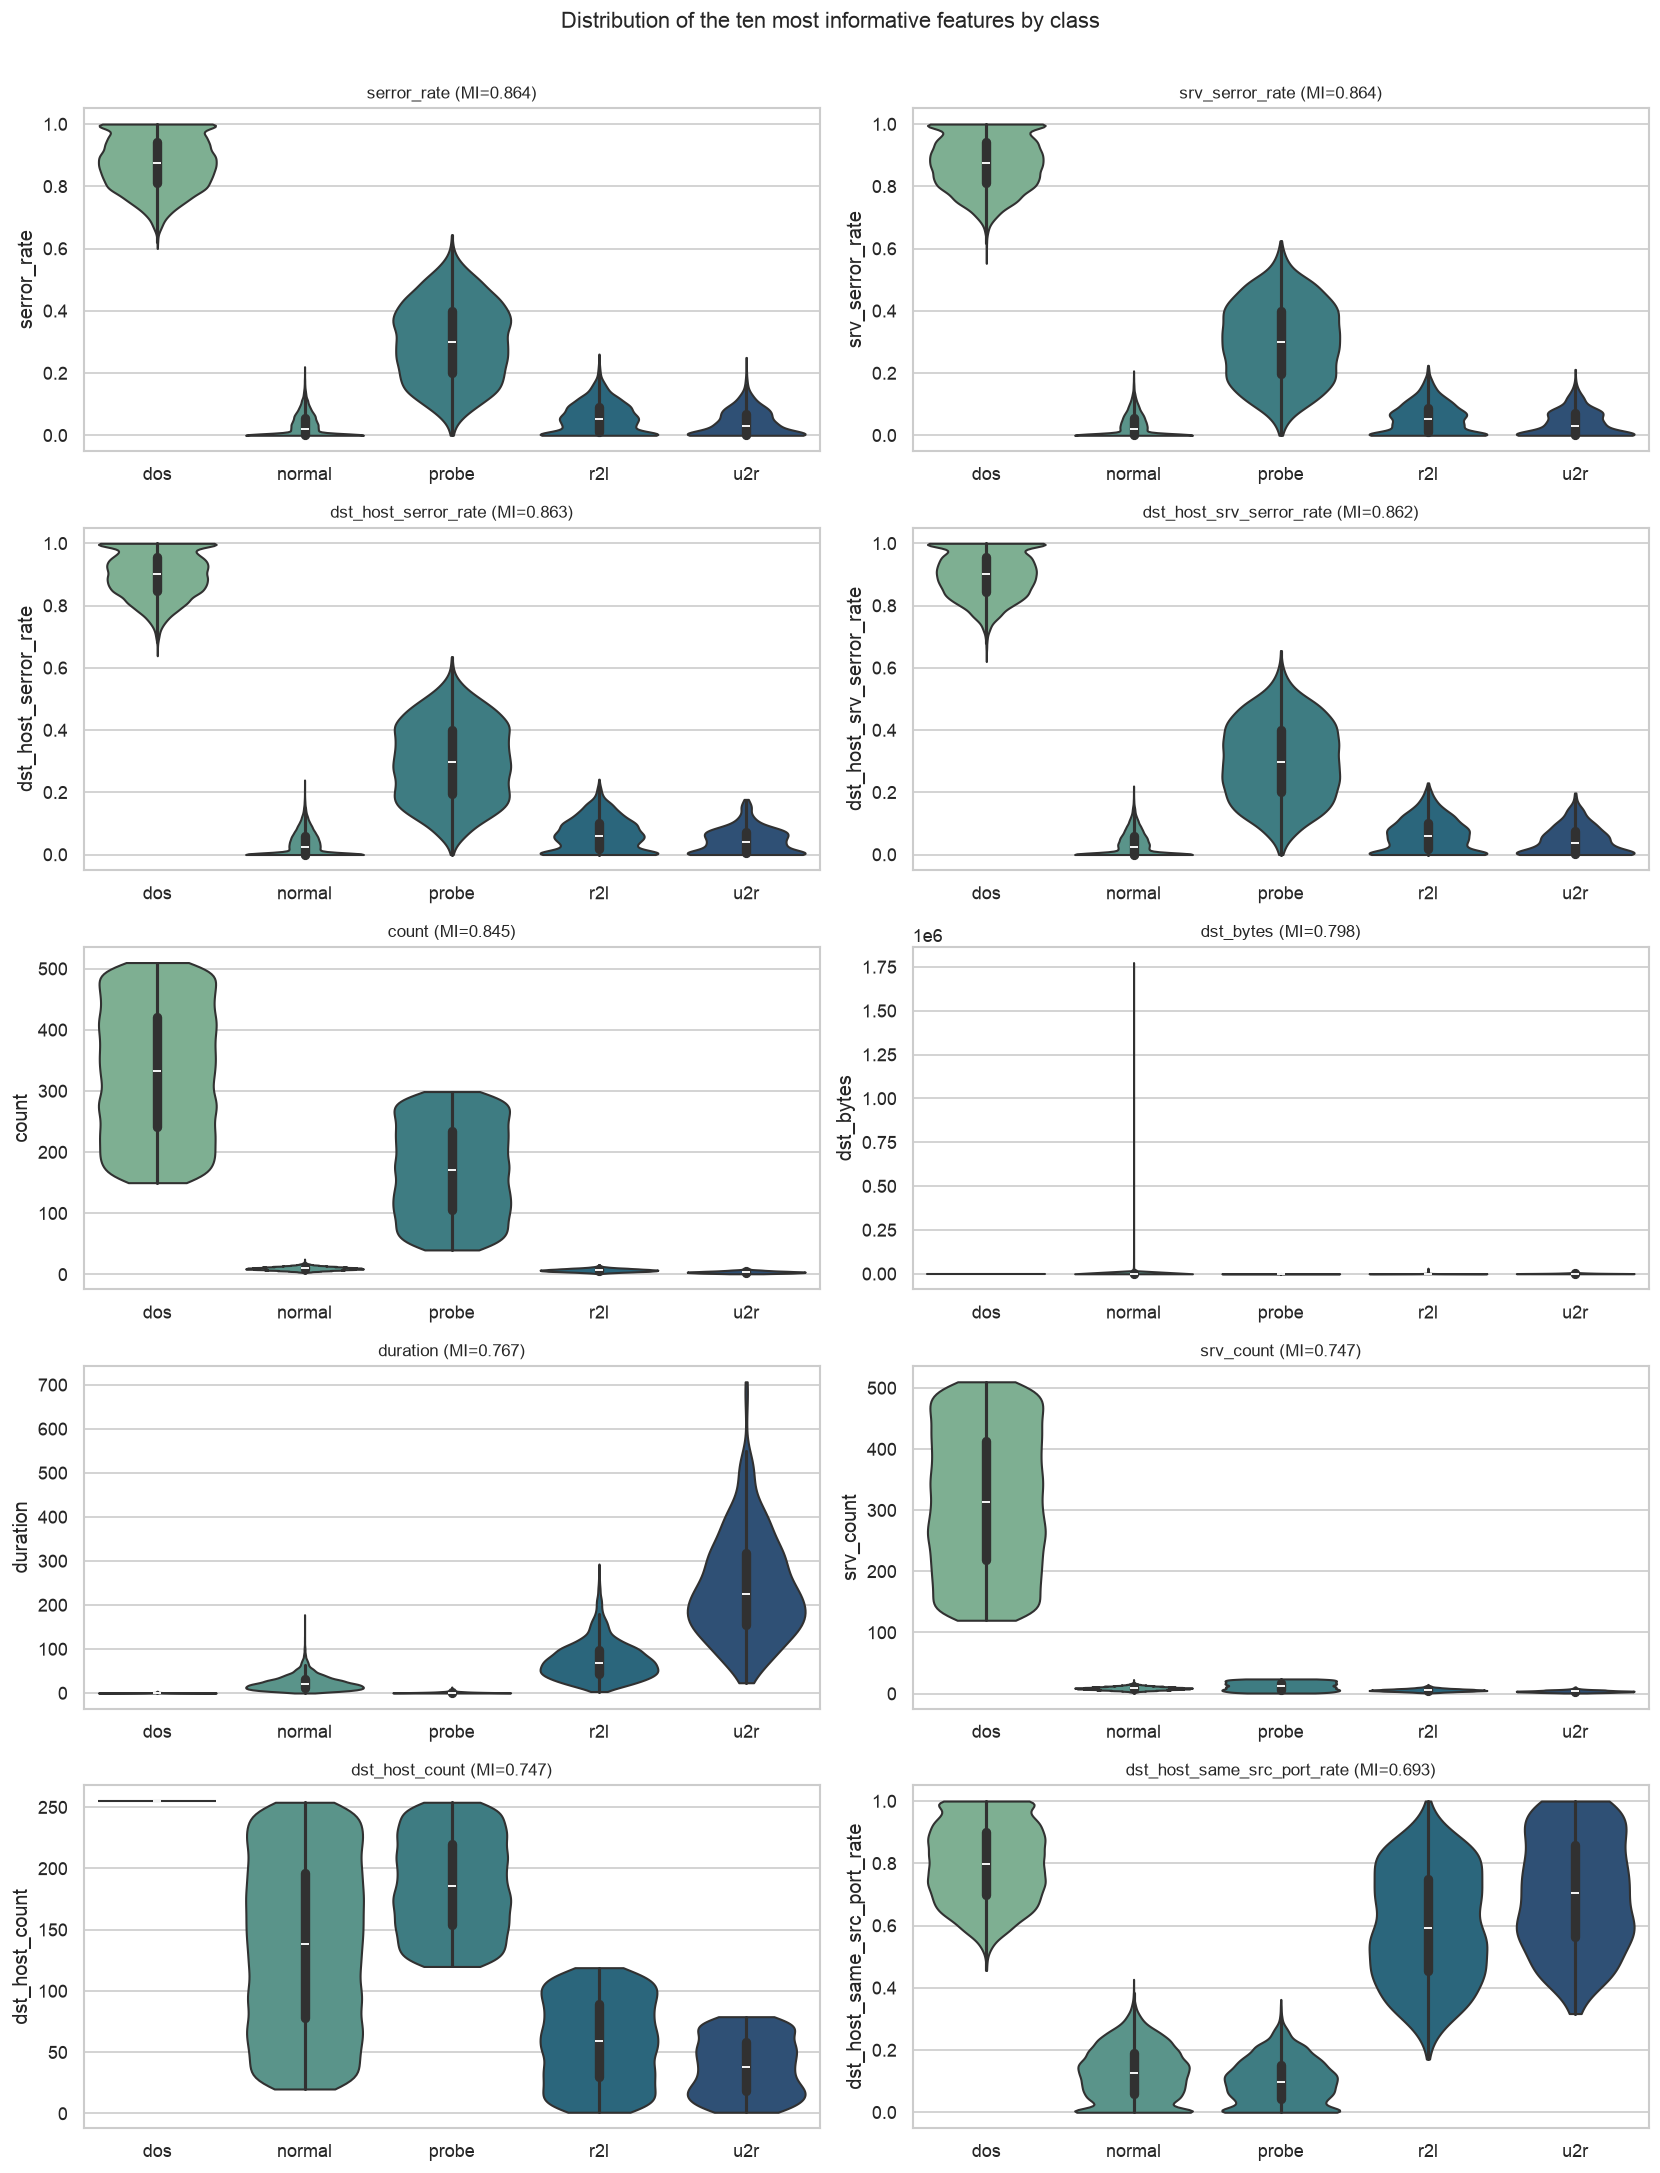

In [8]:
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
for ax, feature in zip(axes.ravel(), top_features.index):
    sns.violinplot(data=flows, x=TARGET, y=feature, hue=TARGET, palette='crest',
                   legend=False, cut=0, ax=ax)
    ax.set_title(f'{feature} (MI={top_features[feature]:.3f})', fontsize=10)
    ax.set_xlabel('')
fig.suptitle('Distribution of the ten most informative features by class', y=1.005,
             fontsize=13)
fig.tight_layout()
plt.show()

## 7. PCA projection

2026-07-27 23:39:26 | INFO     | src.features.engineer:engineer_features - Feature engineering added 22 column(s); total 64


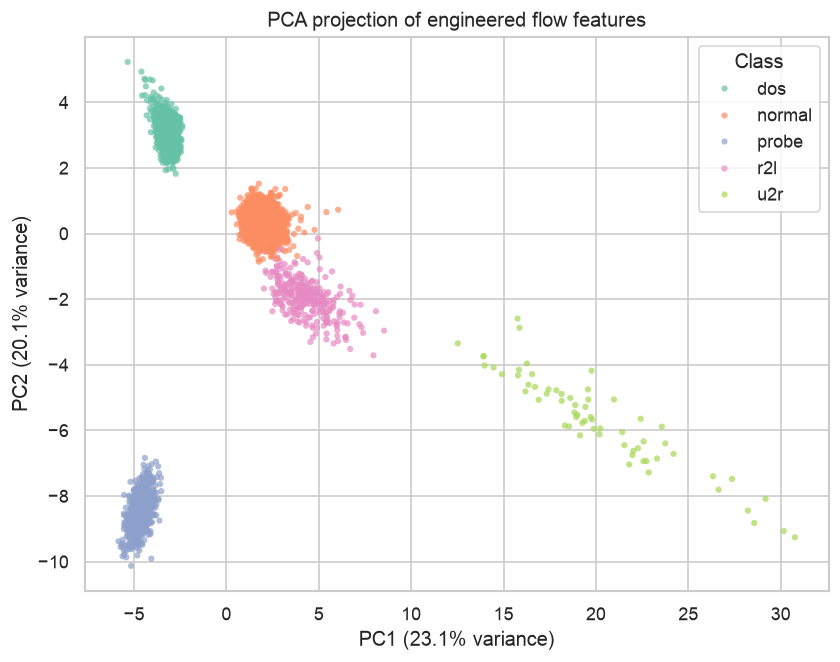

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

engineered = engineer_features(flows)
matrix = engineered.select_dtypes(include=[np.number]).fillna(0)
sample = matrix.sample(min(6000, len(matrix)), random_state=42)
labels = flows.loc[sample.index, TARGET]

components = PCA(n_components=2, random_state=42).fit(StandardScaler().fit_transform(sample))
projected = components.transform(StandardScaler().fit_transform(sample))

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x=projected[:, 0], y=projected[:, 1], hue=labels, palette='Set2', s=14,
                alpha=0.7, edgecolor='none', ax=ax)
ax.set_xlabel(f'PC1 ({components.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({components.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA projection of engineered flow features')
ax.legend(title='Class', loc='best')
plt.show()

## 8. Findings

- The dataset is imbalanced: normal traffic dominates while `u2r` accounts for roughly one percent of flows, so macro-averaged metrics and class weighting matter more than accuracy.
- Error-rate counters (`serror_rate`, `rerror_rate` and their `dst_host_` variants) separate denial-of-service and probe traffic sharply.
- Byte volumes are heavy tailed, which is why the pipeline scales features and derives log and rate variants.
- The PCA projection shows attack families forming distinct regions, supporting the strong cross-validated scores of the tree-based models.